In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import load_properties_bundle, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

/home/junior/Documents/self_organization_percolation/jupyter/src/TimeSeriesAnalysis.py:17: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.interpolate import interp1d


In [2]:
results = "../results/parameters_effects"
create_folder(results)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
33,bond,3,768,0.006710,0.01,1,1.000,0.6,0.1,1,10,10,0.249808,0.000003,6262.40,273.644506,4.554752e+07,1.081797e+06
34,bond,3,1024,0.006710,0.01,1,1.000,0.6,0.1,1,5,5,0.249260,0.000002,8696.80,431.721600,9.809558e+07,3.061865e+06
41,bond,3,1024,0.007229,0.01,1,1.000,0.6,0.1,1,5,5,0.249343,0.000002,8330.60,340.426732,1.000673e+08,2.581193e+06
48,bond,3,1024,0.007748,0.01,1,1.000,0.6,0.1,1,5,5,0.249448,0.000002,8206.40,331.181763,1.035959e+08,2.676646e+06
52,bond,3,512,0.008267,0.01,1,1.000,0.6,0.1,1,25,25,0.249828,0.000004,3847.84,116.186469,1.755755e+07,2.491502e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16928,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,6,52,52,1.000000,0.000000,383.00,0.000000,7.184269e+04,1.939077e+03
16929,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,7,52,52,1.000000,0.000000,383.00,0.000000,7.188169e+04,2.066440e+03
16930,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,8,52,52,1.000000,0.000000,383.00,0.000000,7.524896e+04,2.301396e+03
16931,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


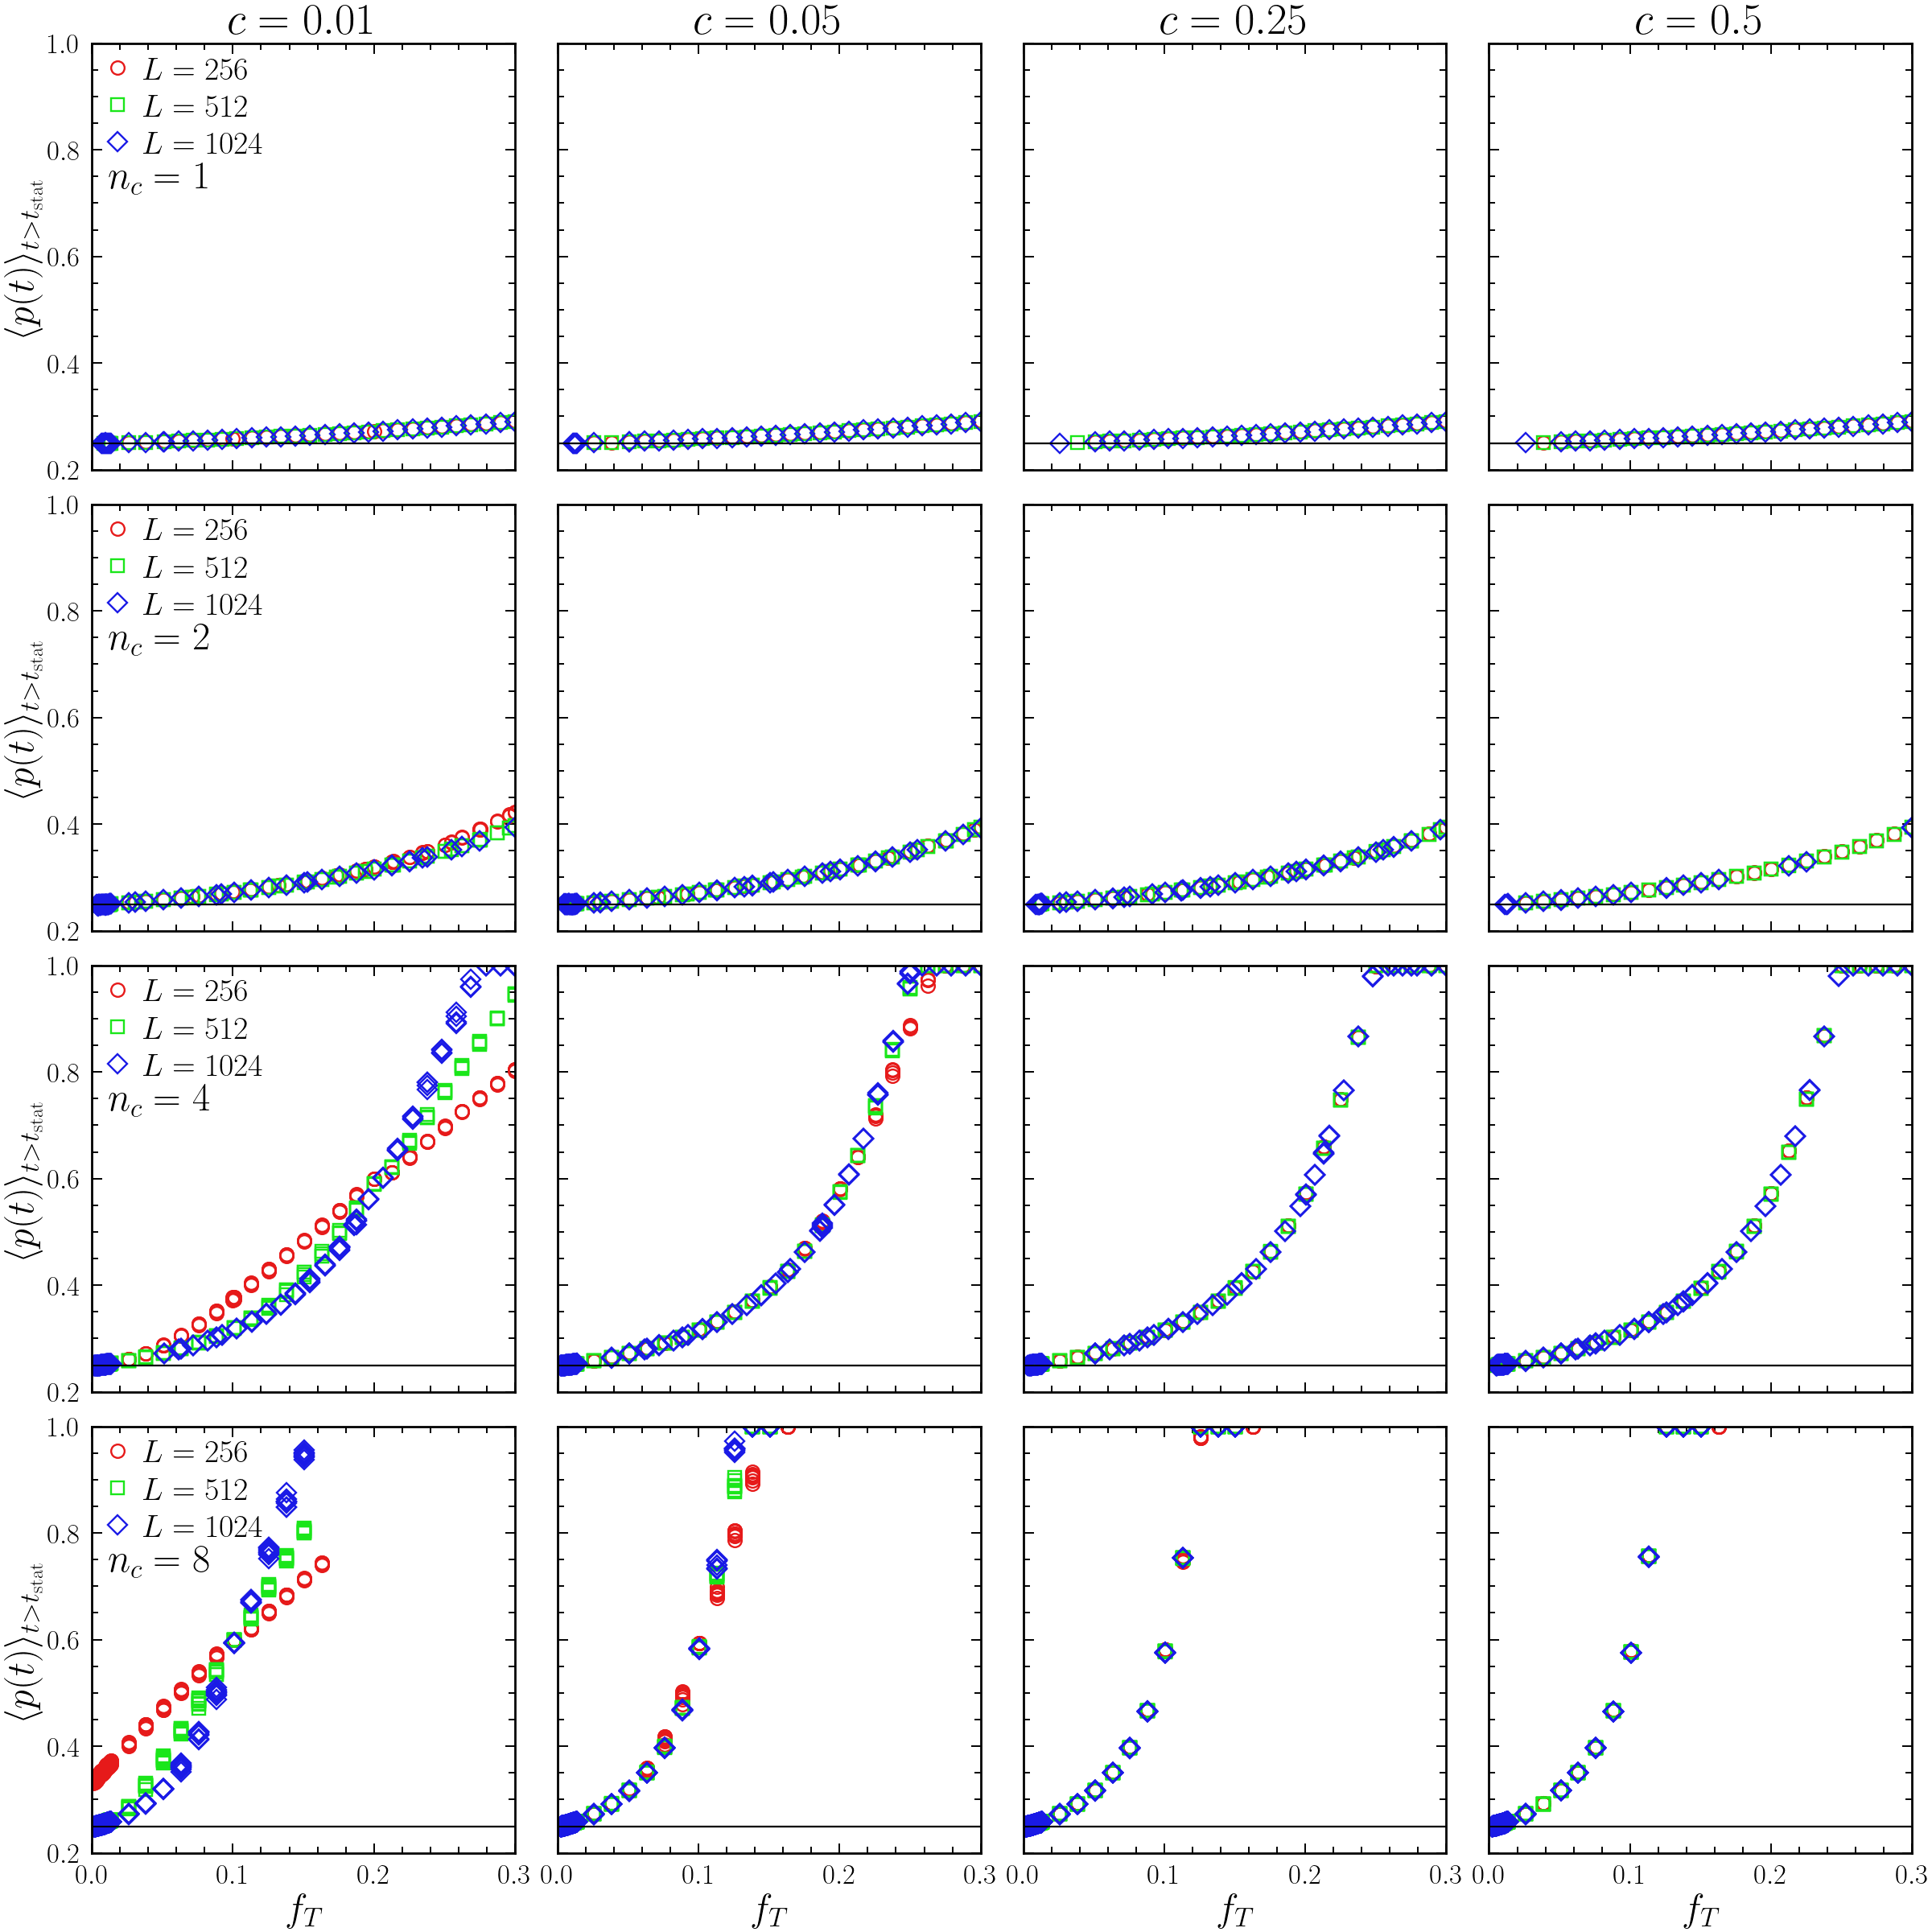

In [4]:
L_lst = [256, 512, 1024]
#L_lst = [256]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1

base = 6
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(len(nc_lst), len(c_lst), figsize=(len(c_lst)*base, len(nc_lst)*base), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']

mew = 1.7
pc = 0.24881182
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 25
labels_size = 35
ms = 12

for idx_nc, nc in enumerate(nc_lst):
    ymax = 0
    for idx_c, c in enumerate(c_lst):
        for idx, L in enumerate(L_lst):
            ax = axes[idx_nc, idx_c]
            df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
            f_t = df_b['f_T']
            pmean = df_b['p_mean']
            ax.plot(f_t, pmean, marker=markers[idx],ms=ms, mew = mew, ls='None', label=f'$L={L}$')
            ax.axhline(pc, color='k', ls='solid')
            y_max = max(ymax, max(pmean))
        
        if(idx_c==0):
            ax.text(0.04, 0.66, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylabel(r'$\langle p(t) \rangle_{t>t_\mathrm{stat}}$', fontsize=labels_size)
            ax.legend(fontsize=fs_legend,loc='upper left', frameon=False)
        if idx_nc==0:
            ax.set_title(f'$c={c}$', fontsize=fs_title)
        if(idx_nc==len(nc_lst)-1):
            
            ax.set_xlim(0, 0.5)
            #ax.set_ylim(0.2, 1.0)
            ax.set_xlabel(r'$f_T$', fontsize=labels_size)
        ax.set_ylim(0.2, y_max)
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='both', which='minor', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='x', which='minor', pad=6)
        ax.tick_params(axis='y', which='minor', pad=6)
        ax.set_xlim(0, 0.3)
        
plt.savefig(f"{results}/p_mean_vs_f_T.png", dpi=300)
plt.show()

In [5]:
import numpy as np
import pandas as pd

L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1

df_sub = df[
    (df["nc"].isin(nc_lst)) &
    (df["L"].isin(L_lst)) &
    (df["c"].isin(c_lst)) &
    (df["type_perc"] == "bond") &
    (df["p0"] == p0) &
    (df["P0"] == P0)
].copy()

# Evita problemas de comparação entre floats
df_sub["f_T_round"] = df_sub["f_T"].round(12)

# Identifica quais f_T aparecem para todos os tamanhos L
df_common = (
    df_sub
    .groupby(["nc", "c", "f_T_round"])["L"]
    .nunique()
    .reset_index(name="n_L")
)

df_common = df_common[df_common["n_L"] == len(L_lst)].copy()

def get_ft_summary(ft_values):
    vals = np.sort(ft_values.to_numpy())

    f_min = vals[0]
    f_max = vals[-1]

    # Ponto médio do intervalo
    f_target = 0.5 * (f_min + f_max)

    # Escolhe o f_T comum mais próximo do ponto médio
    f_mid = vals[np.argmin(np.abs(vals - f_target))]

    return pd.Series({
        "f_T_min_common": f_min,
        "f_T_mid_common": f_mid,
        "f_T_max_common": f_max,
        "n_f_T_common": len(vals)
    })


df_ft_common = (
    df_common
    .groupby(["nc", "c"])["f_T_round"]
    .apply(get_ft_summary)
    .reset_index()
)

df_ft_common

,nc,c,level_2,f_T_round
0,1,0.01,f_T_min_common,0.025917
1,1,0.01,f_T_mid_common,0.165125
2,1,0.01,f_T_max_common,0.300000
3,1,0.01,n_f_T_common,27.000000
4,1,0.05,f_T_min_common,0.025917
...,...,...,...,...
59,8,0.25,n_f_T_common,24.000000
60,8,0.50,f_T_min_common,0.007748
61,8,0.50,f_T_mid_common,0.075750
62,8,0.50,f_T_max_common,0.150500


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parâmetros
# =========================
c = 0.15
L_lst = [256, 512, 1024]
dim = 3
nc_lst = [1, 2, 4, 8]

p0 = 0.6
P0 = 0.1
order_mean = 0

pc = 0.24881182

base = 5

fig, axes = plt.subplots(
    len(nc_lst),
    len(L_lst),
    figsize=(3*base, 4*base),
    constrained_layout=True,
    sharex=True,
    sharey='row'
)

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.00, 0.60, 0.30),  # green
    (0.10, 0.10, 0.90),  # blue
]

ft_cols = [
    "f_T_min_common",
    "f_T_mid_common",
    "f_T_max_common"
]

ft_names = [
    r"$f_T^{\min}$",
    r"$f_T^{\mathrm{mid}}$",
    r"$f_T^{\max}$"
]

labels_fig = [
    r'$(a)$', r'$(b)$', r'$(c)$',
    r'$(d)$', r'$(e)$', r'$(f)$',
    r'$(g)$', r'$(h)$', r'$(i)$',
    r'$(j)$', r'$(k)$', r'$(l)$',
]

fs_labels_fig = 30
fs_l_fig = 27
fs_legend = 22

t_max = 0
parms_need = []

# =========================
# Plot
# =========================
for idx_nc, nc in enumerate(nc_lst):

    # Pega os f_T comum para este par (nc, c)
    row_ft = df_ft_common[
        (df_ft_common["nc"] == nc) &
        (np.isclose(df_ft_common["c"], c))
    ]

    if row_ft.empty:
        print(f"Nenhum f_T comum encontrado para nc = {nc}, c = {c}")
        continue

    row_ft = row_ft.iloc[0]

    fT_values = []
    fT_labels = []

    for col, name in zip(ft_cols, ft_names):
        fT = row_ft[col]

        if np.isfinite(fT):
            fT_values.append(float(fT))
            fT_labels.append(name)

    # Remove valores repetidos, caso f_T_min = f_T_mid ou f_T_mid = f_T_max
    unique_pairs = []
    for fT, label in zip(fT_values, fT_labels):
        if not any(np.isclose(fT, old_fT) for old_fT, _ in unique_pairs):
            unique_pairs.append((fT, label))

    for idx_L, L in enumerate(L_lst):

        ax = axes[idx_nc, idx_L]
        rho = 1 / nc

        for idx_fT, (fT, fT_label) in enumerate(unique_pairs):

            path = (
                f"../SOP_data/published/bond_percolation/"
                f"num_colors_{nc}/dim_{dim}/L_{L}/"
                f"fT_constant/fT_{fT:.6e}/"
                f"c_{c:.6e}/rho_{rho:.4e}"
            )

            fn = path + "/properties_mean_bundle.json"

            try:
                bundle = load_properties_bundle(fn)

                try:
                    data = bundle[p0]["orders"][order_mean]

                except KeyError:
                    print(f"KeyError: nc={nc}, L={L}, c={c}, fT={fT}, p0={p0}")
                    parms_need.append((nc, L, c, fT, p0))
                    continue

                time = data["time"]
                pt_mean = data["pt_mean"]

                ax.plot(
                    time,
                    pt_mean,
                    ls='solid',
                    color=colors[idx_fT],
                    label=fr"{fT_label} $= {fT:.3f}$"
                )

                t_max = max(t_max, max(time))

            except FileNotFoundError:
                print(f"File not found: {fn}")
                parms_need.append((nc, L, c, fT, p0))
                continue

        ax.axhline(pc, color='k', ls='solid')
        ax.set_box_aspect(1)

        if idx_L == 0:
            ax.text(
                0.08,
                0.9,
                fr"$n_c = {nc}$",
                transform=ax.transAxes,
                fontsize=fs_l_fig
            )

            leg = ax.legend(
                fontsize=fs_legend,
                handlelength=1.8,
                handletextpad=0.6,
                borderpad=0.4,
                labelspacing=0.4
            )

            for line in leg.get_lines():
                line.set_linewidth(2.0)

        if idx_nc == 0:
            ax.set_title(fr"$L = {L}$", fontsize=fs_l_fig)

        # Mesma lógica de escala em y do seu código original
        if idx_nc == 0 or idx_nc == 1:
            ax.set_ylim(0.2, 0.3)
        elif idx_nc == 2:
            ax.set_ylim(0.2, 0.35)
        elif idx_nc == 3:
            ax.set_ylim(0.2, 0.8)

# =========================
# Ajustes finais
# =========================
for idx, ax in enumerate(axes.flatten()):
    ax.set_xlim(0, t_max)
    ax.text(
        0.86,
        0.13,
        labels_fig[idx],
        transform=ax.transAxes,
        fontsize=fs_labels_fig
    )

for ax in axes[:, 0]:
    ax.set_ylabel(r'$\langle p(t) \rangle_{\mathrm{samples}}$')

for ax in axes[-1, :]:
    ax.set_xlabel(r'$t$')

plt.show()

Nenhum f_T comum encontrado para nc = 1, c = 0.15
Nenhum f_T comum encontrado para nc = 2, c = 0.15
Nenhum f_T comum encontrado para nc = 4, c = 0.15
Nenhum f_T comum encontrado para nc = 8, c = 0.15


/tmp/ipykernel_3874/3077615358.py:177: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(0, t_max)


IndexError: index out of range

<Figure size 1500x2000 with 12 Axes>

/tmp/ipykernel_3960/347013709.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0.0, 0.05)


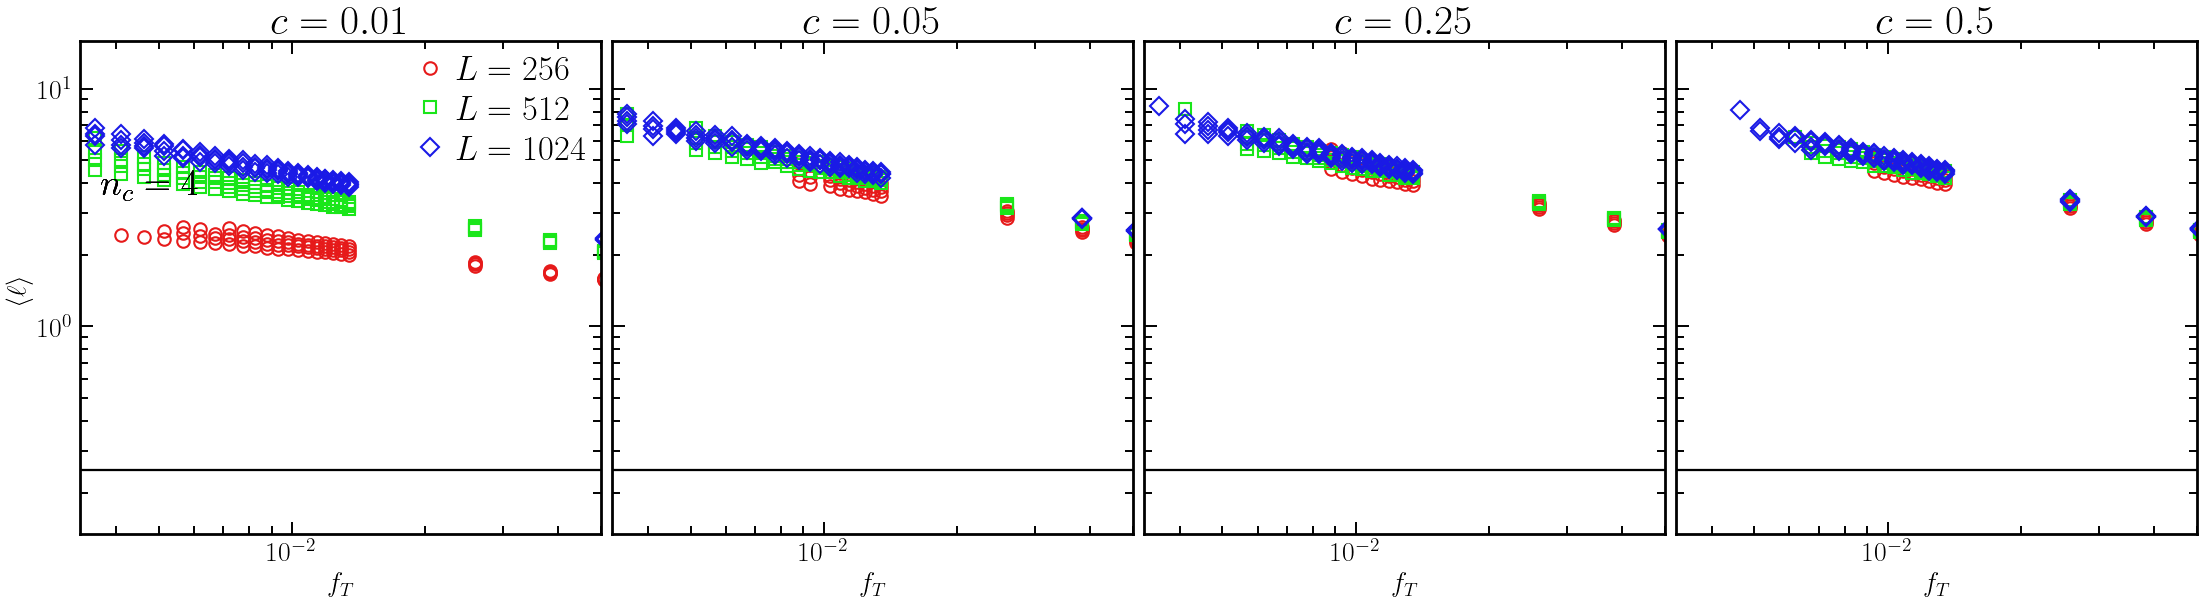

In [15]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 4
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T'] 
        pmean = df_b['shortest_path'] / L
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle \ell \rangle$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim(0.0, 0.05)
plt.show()

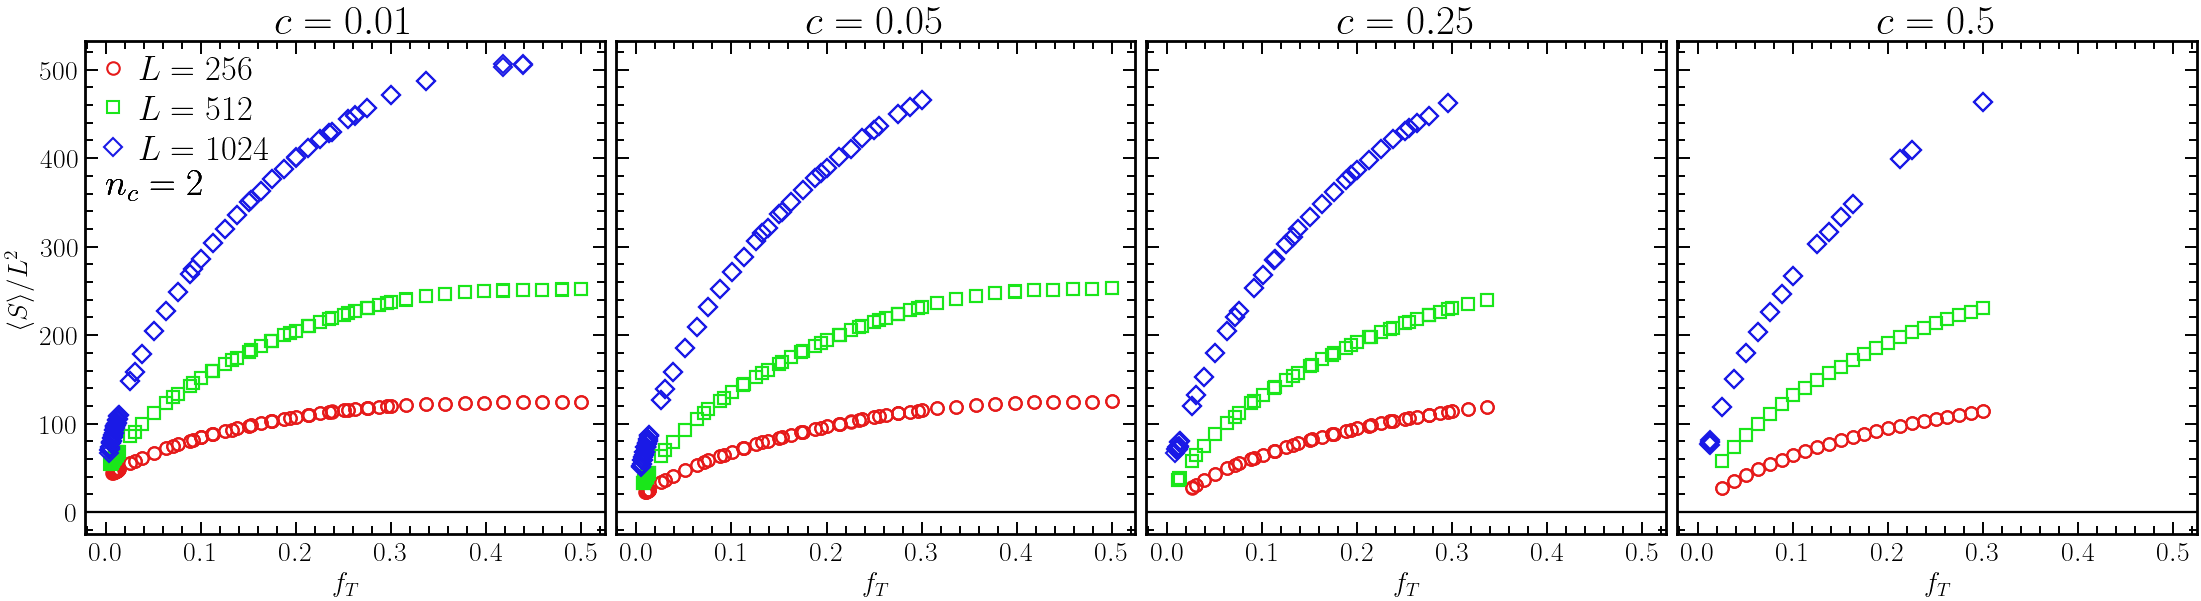

In [16]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 2
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T']
        pmean = df_b['S_perc'] / L**2
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle S \rangle/L^2$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
plt.show()